In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

df =pd.read_csv(r"C:\Users\cocle\Downloads\Metro_Interstate_Traffic_Volume.csv", encoding="latin-1")
print("Shape:",df.shape)
print(df.sample(10))
print(df.info)
print("Statistical summary of data:", df.describe)


Shape: (48204, 9)
      holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
7150      NaN  291.89     2.54      0.0          76         Mist   
29521     NaN  266.43     0.00      0.0          90         Snow   
6769      NaN  283.37     0.25      0.0          68         Rain   
23651     NaN  290.15     0.00      0.0          75       Clouds   
1553      NaN  270.12     0.00      0.0          90       Clouds   
10768     NaN  263.82     0.00      0.0          64       Clouds   
11641     NaN  248.15     0.00      0.0          40       Clouds   
38655     NaN  277.88     0.00      0.0          90         Mist   
26174     NaN  292.56     2.54      0.0           1      Drizzle   
4557      NaN  276.07     0.00      0.0           1        Clear   

      weather_description            date_time  traffic_volume  
7150                 mist  2013-06-23 05:00:00             635  
29521   light shower snow  2016-12-26 15:00:00            3946  
6769           light rain  2013-06-07 

<h3>Data Preprocessing</h3>

In [2]:
# checking missing and duplicates - 
print("Null values:", df.isna().sum()) 
print("Duplicates:",df.duplicated().sum())

# ensure datetime parsed 
df["date_time"] = pd.to_datetime(df["date_time"])

Null values: holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64
Duplicates: 17


In [3]:
# filling missing values (Nan represent no holidays, replacing with 0)
df["holiday"] = df["holiday"].fillna("No-Holiday")

print(df.isna().sum())

# dropping duplicates values 
df=df.drop_duplicates()
print(df.duplicated().sum())

holiday                0
temp                   0
rain_1h                0
snow_1h                0
clouds_all             0
weather_main           0
weather_description    0
date_time              0
traffic_volume         0
dtype: int64
0


<h2>EDA --> univariate analysis</h2>

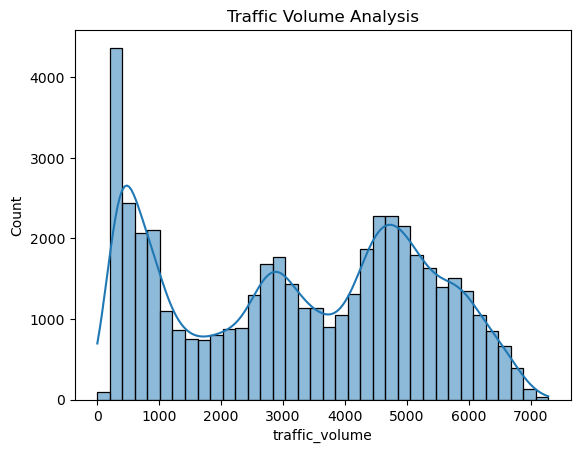

In [4]:
sns.histplot(data=df, x="traffic_volume", kde=True) 
plt.title("Traffic Volume Analysis") 
plt.show()

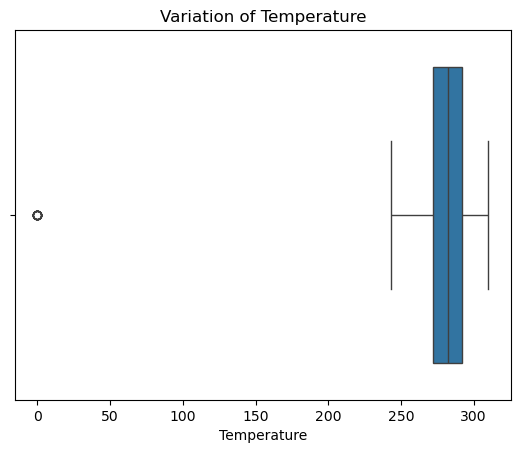

In [5]:
sns.boxplot(data=df, x="temp") 
plt.title("Variation of Temperature") 
plt.xlabel("Temperature")
plt.show()

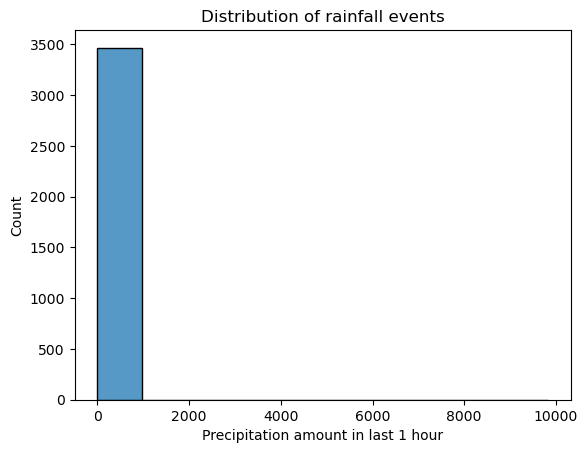

In [6]:
# 'rain_1h' columns had very few values greater than 1, other values are zero. 
# so, we used a filtering condition
rain_only = df[df["rain_1h"]>0] 

sns.histplot(data=rain_only, x="rain_1h", bins=10) 
plt.title("Distribution of rainfall events") 
plt.xlabel("Precipitation amount in last 1 hour") 
plt.show()

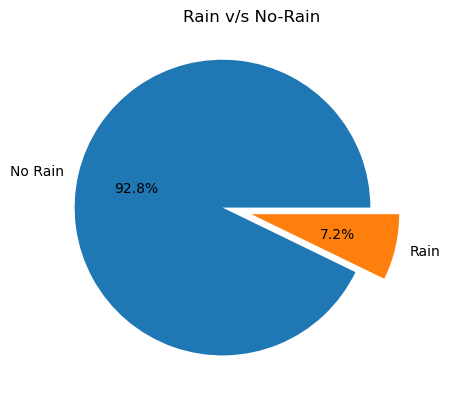

In [7]:
rain_count = (df["rain_1h"]>0).value_counts() 

plt.pie(rain_count, labels=["No Rain","Rain"], autopct="%1.1f%%",explode=(0.2,0))
plt.title("Rain v/s No-Rain")
plt.show()

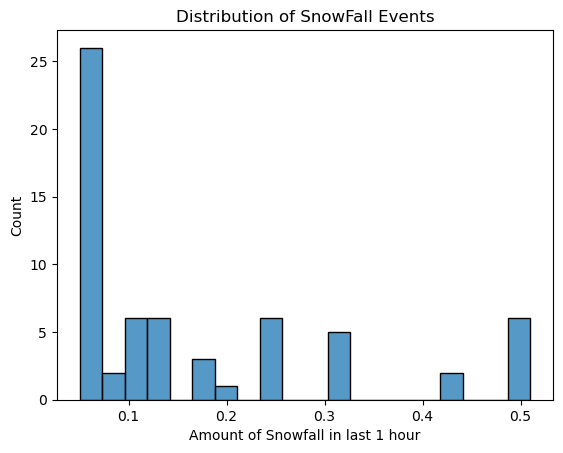

In [8]:
snow_only = df[df["snow_1h"]>0] 
sns.histplot(data=snow_only, x="snow_1h",bins=20) 
plt.title("Distribution of SnowFall Events")
plt.xlabel("Amount of Snowfall in last 1 hour") 
plt.show()

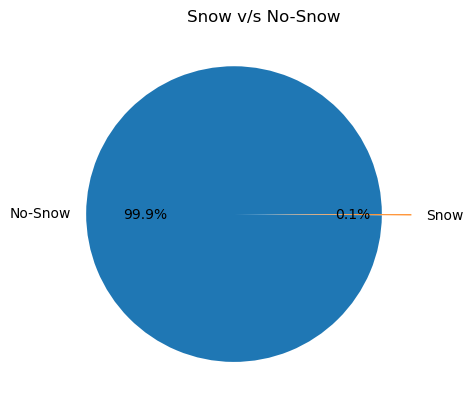

In [9]:
snow_count = (df["snow_1h"]>0).value_counts()

plt.pie(snow_count, labels=["No-Snow","Snow"], autopct="%1.1f%%",explode=(0.2,0)) 
plt.title("Snow v/s No-Snow") 
plt.show() 

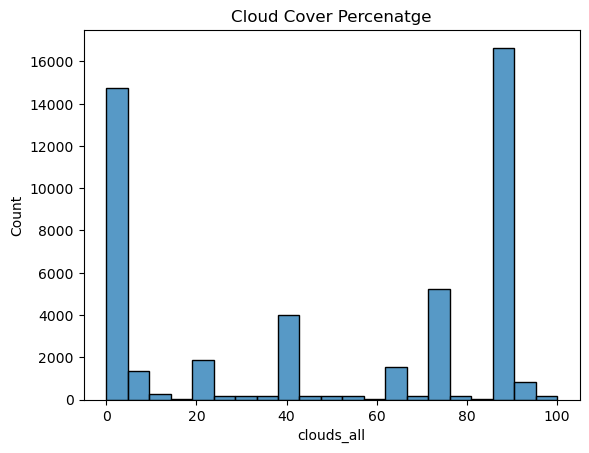

In [10]:
sns.histplot(data=df, x="clouds_all") 
plt.title("Cloud Cover Percenatge") 
plt.show()

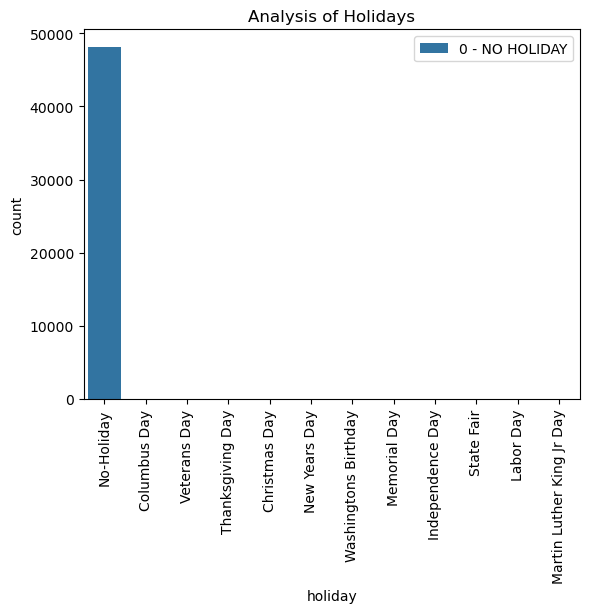

Non-Holiday and Holiday Counts : holiday
No-Holiday                   48126
Labor Day                        7
Thanksgiving Day                 6
Christmas Day                    6
New Years Day                    6
Martin Luther King Jr Day        6
Columbus Day                     5
Veterans Day                     5
Washingtons Birthday             5
Memorial Day                     5
Independence Day                 5
State Fair                       5
Name: count, dtype: int64


In [11]:
sns.countplot(data=df, x="holiday") 
plt.title("Analysis of Holidays") 
plt.legend(labels=["0 - NO HOLIDAY"])
plt.xticks(rotation=90)
plt.show()

print("Non-Holiday and Holiday Counts :", df["holiday"].value_counts())

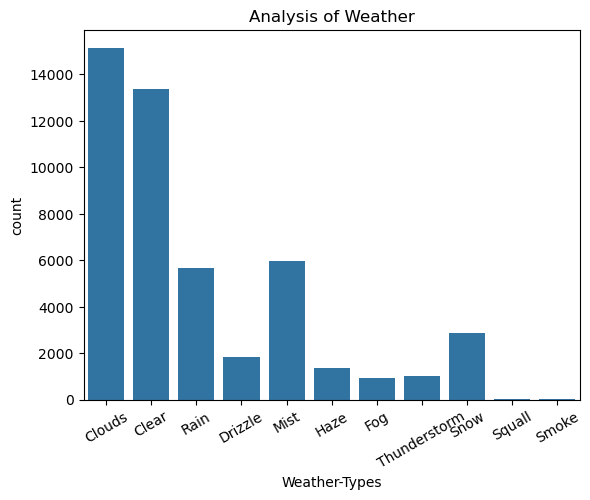

In [12]:
sns.countplot(data=df, x="weather_main")
plt.title("Analysis of Weather") 
plt.xlabel("Weather-Types")
plt.xticks(rotation=30) 
plt.show()

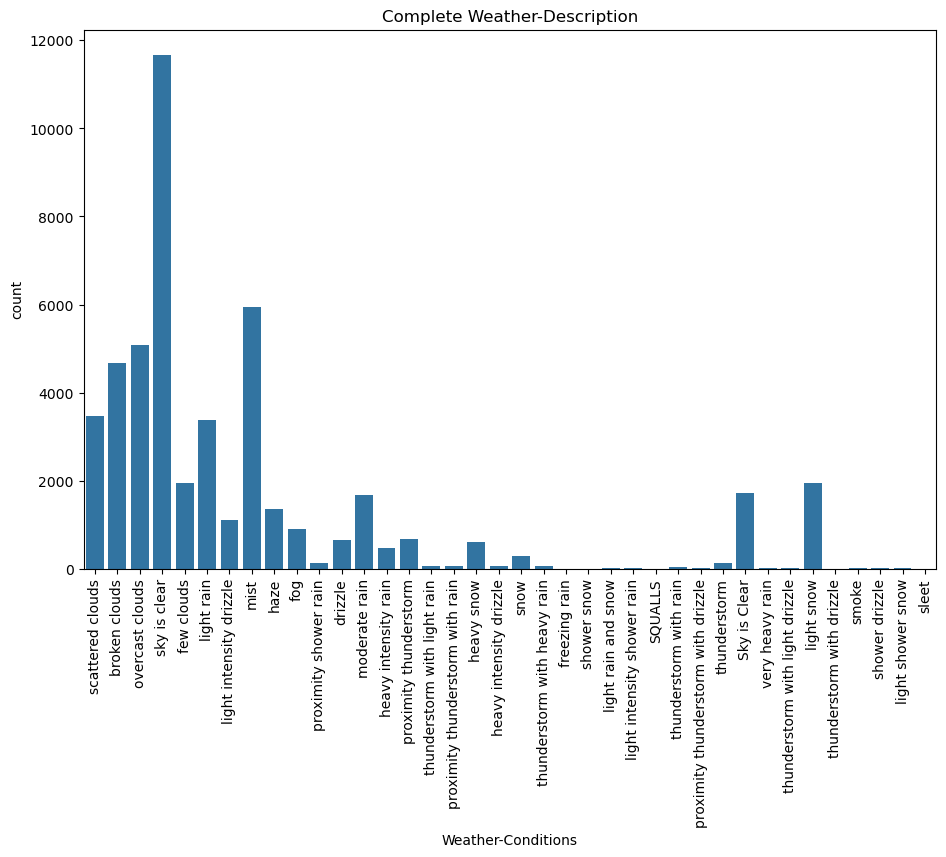

In [13]:
plt.figure(figsize=(11,7))
sns.countplot(data=df, x="weather_description") 
plt.title("Complete Weather-Description")
plt.xlabel("Weather-Conditions") 
plt.xticks(rotation=90)
plt.show()

<h2>Bivariate Analysis</h2>

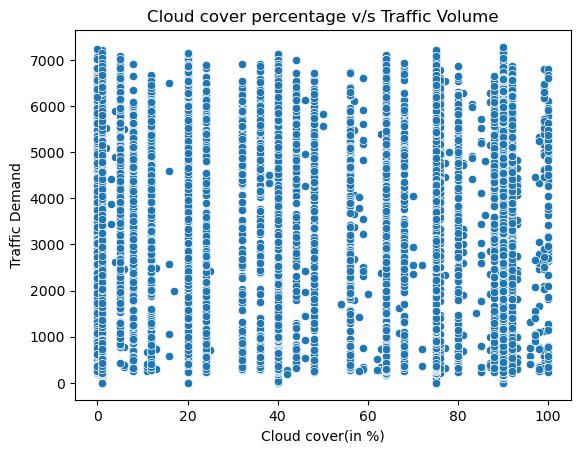

In [14]:
sns.scatterplot(data=df, x="clouds_all", y="traffic_volume")
plt.title("Cloud cover percentage v/s Traffic Volume") 
plt.xlabel("Cloud cover(in %)") 
plt.ylabel("Traffic Demand")
plt.show()

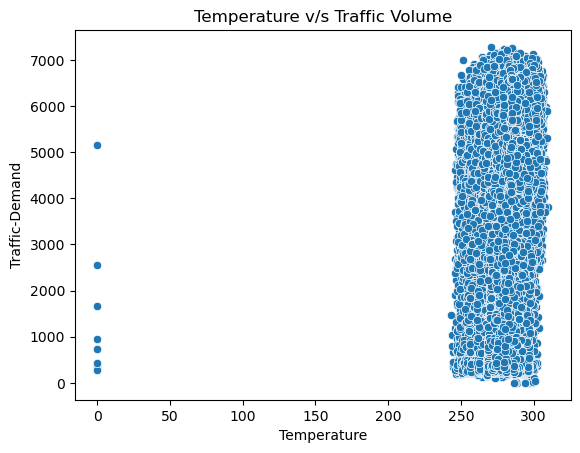

In [15]:
sns.scatterplot(data=df, x="temp", y="traffic_volume")
plt.title("Temperature v/s Traffic Volume") 
plt.xlabel("Temperature") 
plt.ylabel("Traffic-Demand")
plt.show()

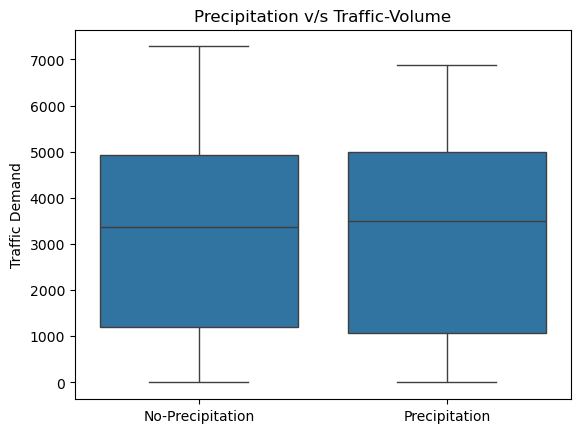

In [16]:
df["rain_or_snow"] = ((df["rain_1h"]+df["snow_1h"])>0).astype(int) 
sns.boxplot(data=df,x="rain_or_snow", y="traffic_volume") 
plt.xticks(ticks=[0,1],labels=["No-Precipitation","Precipitation"]) 
plt.xlabel("") 
plt.ylabel("Traffic Demand") 
plt.title("Precipitation v/s Traffic-Volume")
plt.show()

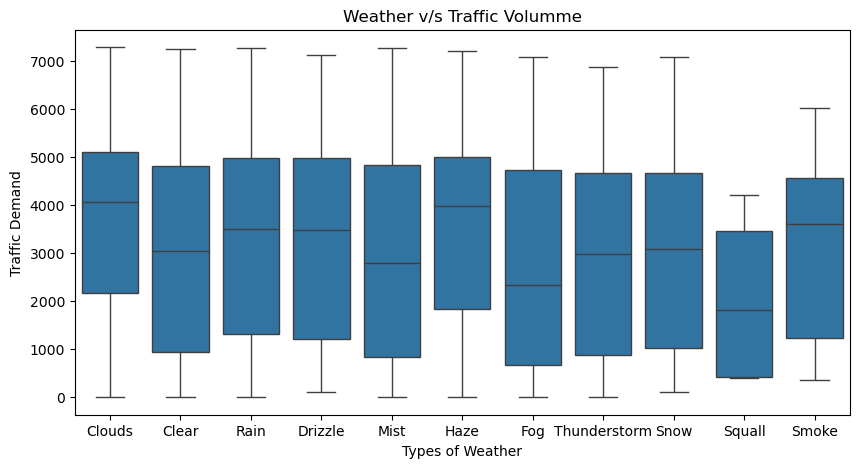

In [17]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="weather_main", y="traffic_volume")
plt.xlabel("Types of Weather")
plt.ylabel("Traffic Demand") 
plt.title("Weather v/s Traffic Volumme") 
plt.show()

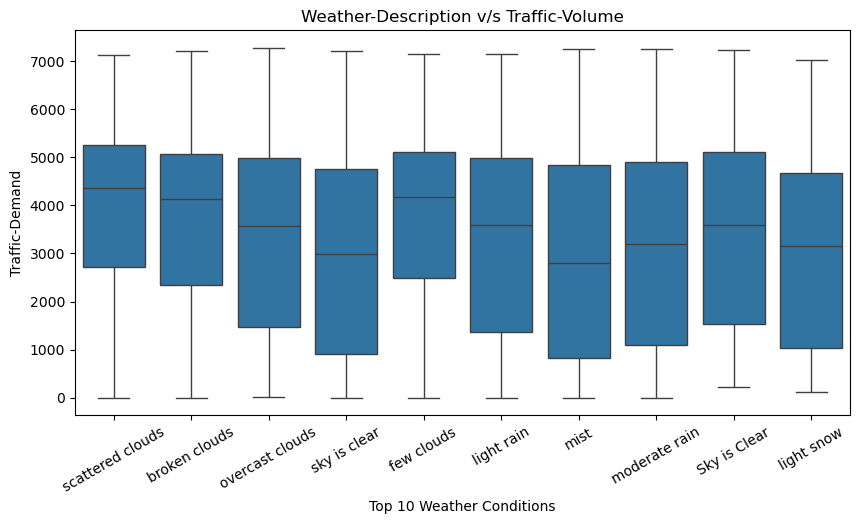

In [18]:
top10_weather = df["weather_description"].value_counts().index[:10] 
plt.figure(figsize=(10,5)) 
sns.boxplot(data=df[df["weather_description"].isin(top10_weather)],x="weather_description",y="traffic_volume") 
plt.xticks(rotation=30)
plt.xlabel("Top 10 Weather Conditions") 
plt.ylabel("Traffic-Demand")
plt.title("Weather-Description v/s Traffic-Volume")
plt.show()

In [19]:
df["month"] = df["date_time"].dt.month_name()  
df["is_weekend"] = df["date_time"].dt.dayofweek>=5

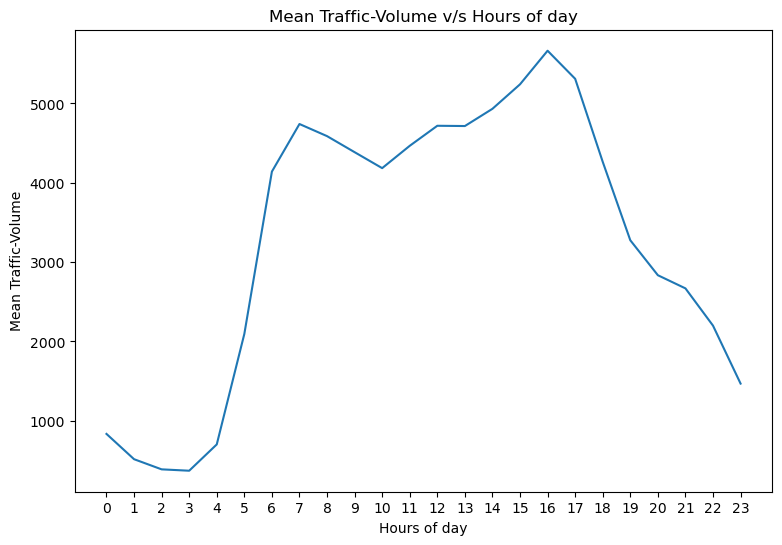

In [20]:
df["hours"] = df["date_time"].dt.hour 
hour = df.groupby("hours")["traffic_volume"].mean().reindex(range(24)) 
plt.figure(figsize=(9,6))
sns.lineplot(x=hour.index, y =hour.values, markers="o") 
plt.xlabel("Hours of day") 
plt.ylabel("Mean Traffic-Volume") 
plt.xticks(range(0,24))
plt.title("Mean Traffic-Volume v/s Hours of day") 
plt.show()

<h3>Multivariate Analysis</h3>

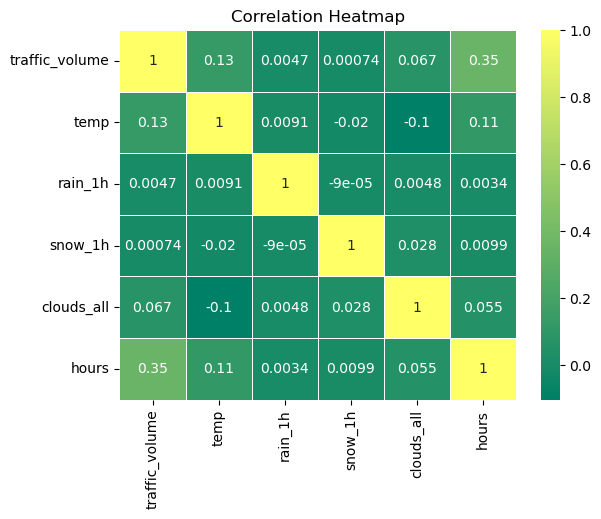

In [21]:
num_cols = ["traffic_volume","temp","rain_1h","snow_1h","clouds_all","hours"]
sns.heatmap(df[num_cols].corr(), annot=True, cmap="summer", linewidths=0.5)
plt.title("Correlation Heatmap") 
plt.show()

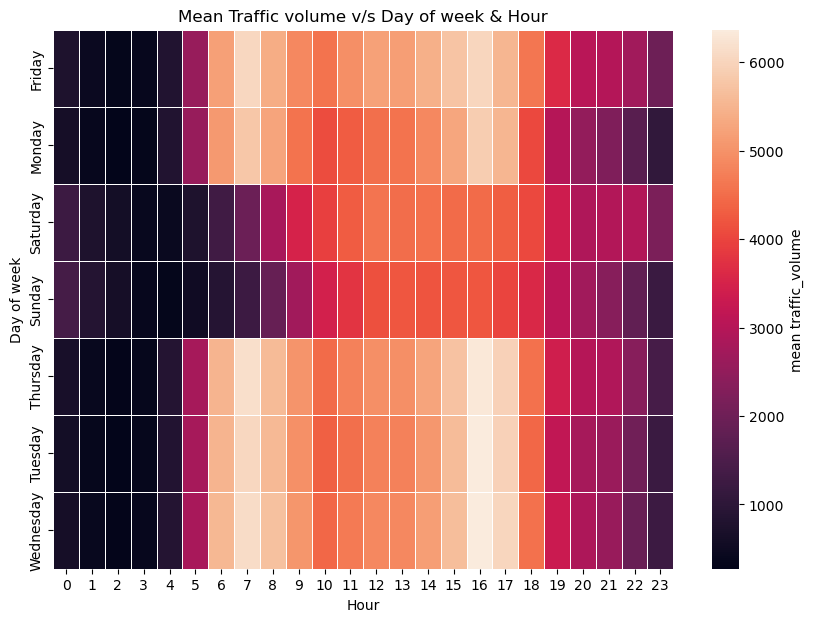

In [22]:
df["dayofweek"] = df["date_time"].dt.day_name()
data = df.pivot_table(index="dayofweek", columns="hours", values="traffic_volume", aggfunc="mean") 
plt.figure(figsize=(10,7))
sns.heatmap(data, cbar_kws={"label":"mean traffic_volume"},linewidths=0.5) 
plt.xlabel("Hour")
plt.ylabel("Day of week")
plt.title("Mean Traffic volume v/s Day of week & Hour") 
plt.show()

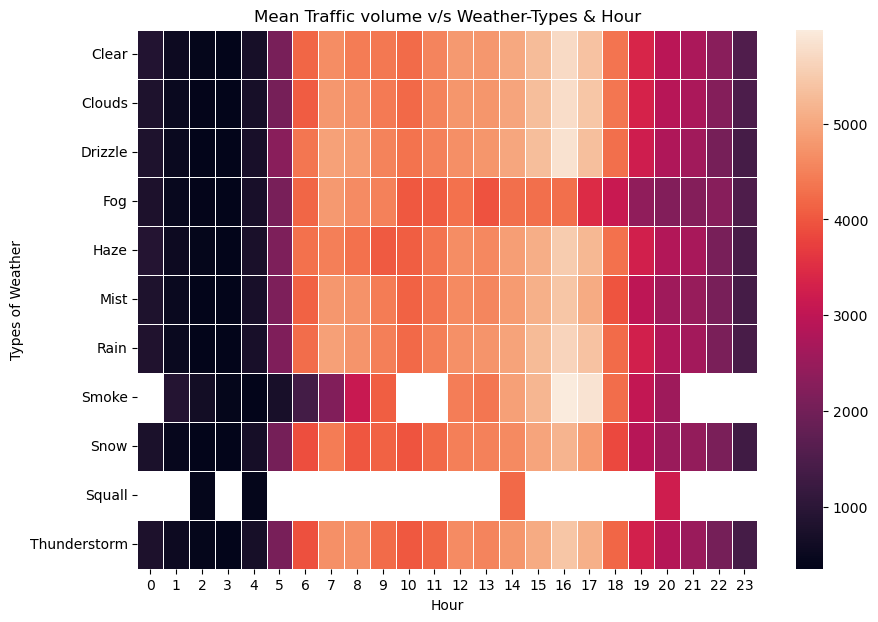

In [23]:
data = df.pivot_table(index="weather_main", columns="hours",values="traffic_volume", aggfunc="mean") 
plt.figure(figsize=(10,7))
sns.heatmap(data,linewidths=0.5) 
plt.xlabel("Hour")
plt.ylabel("Types of Weather")
plt.title("Mean Traffic volume v/s Weather-Types & Hour") 
plt.show()

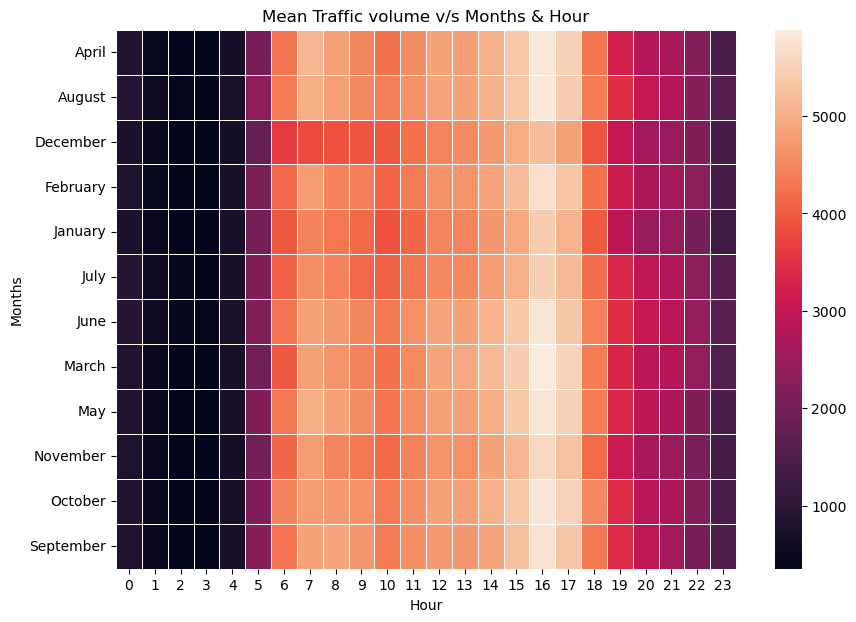

In [24]:
data = df.pivot_table(index="month",columns="hours", values="traffic_volume",aggfunc="mean") 
plt.figure(figsize=(10,7))
sns.heatmap(data, linewidths=0.5) 
plt.xlabel("Hour")
plt.ylabel("Months")
plt.title("Mean Traffic volume v/s Months & Hour") 
plt.show()

<h2>Feature Engineering</h2>

In [25]:
# Peak Hour Flag 
peak_hours = hour.nlargest(4).index
df["peak_hour_flag"] = df["hours"].isin(peak_hours).astype(int)

# Rush Hour Indicator
df["rush_hour"] = np.where(((df["hours"]>=7) & (df["hours"]<=9)) | ((df["hours"]>=16) & (df["hours"]<=18)), 1, 0) 

# Weekend Flag 
df["weekend_flag"] = np.where(df["dayofweek"].isin([5,6]), 1, 0) 

# Weather Impact Score 
df["weather_impact_score"] = (df["rain_1h"]*2 + df["snow_1h"]*3 + df["clouds_all"]/100 )

# Working day Flag 
df["working_day"] = np.where((df["weekend_flag"]==0) & (df["holiday"]=="None"), 1, 0)

# Hour Cyclic encoding 
df["hour_sin"] = np.sin(2*np.pi*df["hours"]/24) 
df["hour_cos"] = np.cos(2*np.pi*df["hours"]/24) 

# encoding "weather_main" 
weather_map = {"Clouds":0,"Clear":1,"Mist":2,"Rain":3,"Snow":4,"Drizzle":5,"Haze":6,"Thunderstorm":7,"Fog":8,"Smoke":9,"Squall":10} 
df["weather_main_new"] = df["weather_main"].map(weather_map) 

# encoding "dayofweek" 
dayofweek_map = {"Sunday":0,"Monday":1,"Tuesday":2,"Wednesday":3,"Thursday":4,"Friday":5,"Saturday":6} 
df["dayofweek_new"] = df["dayofweek"].map(dayofweek_map) 

# encoding "month" 
month_map = {"January":0,"February":1,"March":2,"April":3,"May":4,"June":5,"July":6,"August":7,"September":8,"October":9,"November":10,"December":11} 
df["month_new"] = df["month"].map(month_map) 

# encoding "holiday" 
holiday_map = {"No-Holiday":0,"Labor Day":1,"Thanksgiving Day":2,"Christmas Day":3,"New Years Day":4,"Martin Luther King Jr Day":5,"Columbus Day":6,"Veterans Day":7,
               "Washingtons Birthday":8,"Memorial Day":9,"Independence Day":10,"State Fair":11} 
df["holiday_new"] = df["holiday"].map(holiday_map) 

print(df.columns)
print(df.isna().sum())

Index(['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main',
       'weather_description', 'date_time', 'traffic_volume', 'rain_or_snow',
       'month', 'is_weekend', 'hours', 'dayofweek', 'peak_hour_flag',
       'rush_hour', 'weekend_flag', 'weather_impact_score', 'working_day',
       'hour_sin', 'hour_cos', 'weather_main_new', 'dayofweek_new',
       'month_new', 'holiday_new'],
      dtype='object')
holiday                 0
temp                    0
rain_1h                 0
snow_1h                 0
clouds_all              0
weather_main            0
weather_description     0
date_time               0
traffic_volume          0
rain_or_snow            0
month                   0
is_weekend              0
hours                   0
dayofweek               0
peak_hour_flag          0
rush_hour               0
weekend_flag            0
weather_impact_score    0
working_day             0
hour_sin                0
hour_cos                0
weather_main_new        0
da

In [26]:
# Deriving Correlation with target Variable
Correlation = df.corr(numeric_only=True)["traffic_volume"]
print("Top Positive correlation ------> ") 
print(Correlation[Correlation>0].sort_values(ascending=False)) 
print("Top Negative correlation ------> ") 
print(Correlation[Correlation<0].sort_values())

Top Positive correlation ------> 
traffic_volume          1.000000
rush_hour               0.454132
peak_hour_flag          0.449327
hours                   0.352300
temp                    0.130161
dayofweek_new           0.073680
clouds_all              0.067138
weather_impact_score    0.005007
rain_1h                 0.004715
rain_or_snow            0.003364
snow_1h                 0.000736
Name: traffic_volume, dtype: float64
Top Negative correlation ------> 
hour_cos           -0.764223
hour_sin           -0.244183
is_weekend         -0.218533
weather_main_new   -0.064342
holiday_new        -0.037889
month_new          -0.002480
Name: traffic_volume, dtype: float64


In [27]:
# Firstly, Training the Model with all features  --> Random Forest
# found some features were irrelevant and removed them for training the model.
from sklearn.model_selection import train_test_split 
X = df[["temp","rain_1h","clouds_all","hour_sin","hour_cos","weather_main_new","dayofweek_new",
       "month_new"]]
y = df["traffic_volume"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42) 

0.9544154777368491
RMSE : 426.89990962832064
MAE: 239.37127465192344
            Feature  Importance
4          hour_cos    0.651074
3          hour_sin    0.174734
6     dayofweek_new    0.110981
0              temp    0.036589
7         month_new    0.010544
2        clouds_all    0.007211
5  weather_main_new    0.005940
1           rain_1h    0.002927


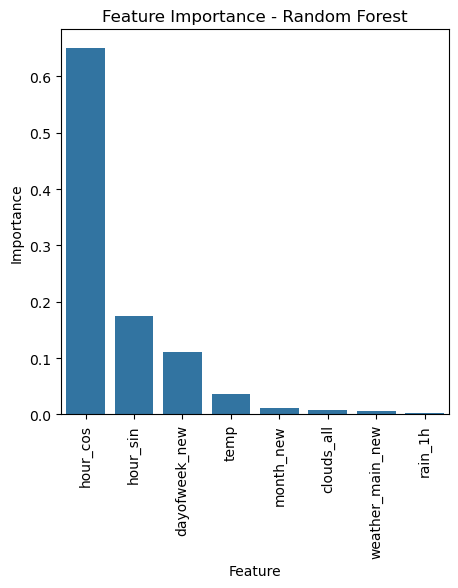

In [28]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_absolute_error,r2_score, root_mean_squared_error) 
rf = RandomForestRegressor(n_estimators = 100, random_state=42) 

rf.fit(X_train, y_train) 
pred = rf.predict(X_test) 

print(r2_score(y_test, pred))
print("RMSE :",root_mean_squared_error(y_test, pred)) 
print("MAE:",mean_absolute_error(y_test, pred))

# FEATURE IMPORTANCE 
df_importance = pd.DataFrame({"Feature":X_train.columns, "Importance":rf.feature_importances_}) 
df_importance = df_importance.sort_values(by="Importance", ascending=False) 
print(df_importance) 

# plotting graph 
plt.figure(figsize=(5,5))
sns.barplot(data=df_importance, x="Feature", y="Importance")
plt.xticks(rotation=90)
plt.title("Feature Importance - Random Forest") 
plt.show()

<h2> XGBOOST IMPLEMENTATION </h2>

In [30]:
from xgboost import XGBRegressor 
xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42) 

xgb.fit(X_train,y_train) 
y_pred_xgb = xgb.predict(X_test)

from sklearn.metrics import (mean_absolute_error,r2_score, root_mean_squared_error) 
print("R2 score:",r2_score(y_test, y_pred_xgb))
print("RMSE :",root_mean_squared_error(y_test, y_pred_xgb)) 
print("MAE:",mean_absolute_error(y_test, y_pred_xgb))

R2 score: 0.9511240720748901
RMSE : 442.0433349609375
MAE: 263.5534973144531


<h4> Tuning XGBoost model </h4>

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Parameters found : {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 0.9}
R2 score: 0.9576378464698792
RMSE : 411.5346984863281
MAE: 246.68832397460938
            Feature  Importance
4          hour_cos    0.728401
3          hour_sin    0.151755
6     dayofweek_new    0.088787
1           rain_1h    0.007580
7         month_new    0.007415
5  weather_main_new    0.006119
0              temp    0.005862
2        clouds_all    0.004081


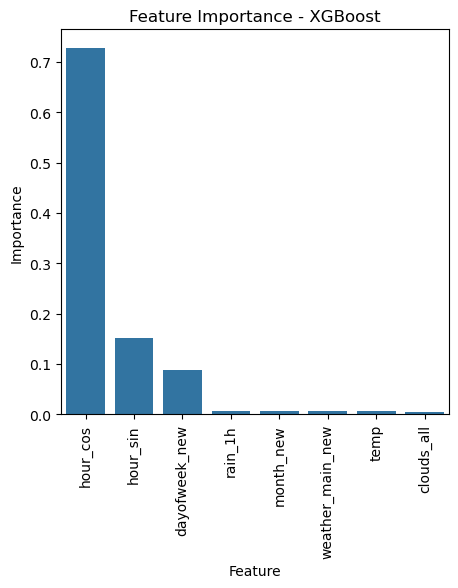

In [31]:
from sklearn.model_selection import RandomizedSearchCV 
param_grid = {"n_estimators":[100,200,300],"learning_rate":[0.01,0.05,0.1,0.2],"max_depth":[3,4,5,6],"subsample":[0.7,0.8,0.9,1],
              "colsample_bytree":[0.7,0.8,0.9,1]} 

xgb_model = XGBRegressor(random_state=42) 

xgb_random_search =RandomizedSearchCV(estimator=xgb_model,param_distributions=param_grid, n_iter=10, scoring="r2", cv=3, verbose=2,
                                      random_state=42, n_jobs=2) 

xgb_random_search.fit(X_train,y_train) 
print("\nBest Parameters found :",xgb_random_search.best_params_) 

xgb_model_tuned = xgb_random_search.best_estimator_ 

y_pred_xgb2 = xgb_model_tuned.predict(X_test)

from sklearn.metrics import (mean_absolute_error,r2_score, root_mean_squared_error) 
print("R2 score:",r2_score(y_test, y_pred_xgb2))
print("RMSE :",root_mean_squared_error(y_test, y_pred_xgb2)) 
print("MAE:",mean_absolute_error(y_test, y_pred_xgb2))

# FEATURE IMPORTANCE 
df_importance2 = pd.DataFrame({"Feature":X_train.columns, "Importance":xgb_model_tuned.feature_importances_}) 
df_importance2 = df_importance2.sort_values(by="Importance", ascending=False) 
print(df_importance2) 

# plotting graph 
plt.figure(figsize=(5,5))
sns.barplot(data=df_importance2, x="Feature", y="Importance")
plt.xticks(rotation=90)
plt.title("Feature Importance - XGBoost") 
plt.show()

<h2>LIGHTGBM REGRESSOR</h2>

In [36]:
from lightgbm import LGBMRegressor 
lgbm = LGBMRegressor(random_state=42, n_estimators=100, learning_rate=0.1,num_leaves=31,n_jobs=2, verbose=-1) 

lgbm.fit(X_train, y_train) 
y_pred_lgbm = lgbm.predict(X_test) 

from sklearn.metrics import (mean_absolute_error,r2_score, root_mean_squared_error) 
print("R2 score:",r2_score(y_test, y_pred_lgbm))
print("RMSE :",root_mean_squared_error(y_test, y_pred_lgbm)) 
print("MAE:",mean_absolute_error(y_test, y_pred_lgbm))

R2 score: 0.9547044957491496
RMSE : 425.5444281188915
MAE: 254.6982436070065


<h4> Tuning LIGHTGBM model </h4>


Best Parameters found: {'subsample': 0.9, 'num_leaves': 40, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
R2 score: 0.9557476769469757
RMSE : 420.6156195244319
MAE: 252.96317612808537
            Feature  Importance
0              temp        2031
6     dayofweek_new        1166
7         month_new        1005
3          hour_sin         960
4          hour_cos         856
2        clouds_all         805
5  weather_main_new         546
1           rain_1h         425


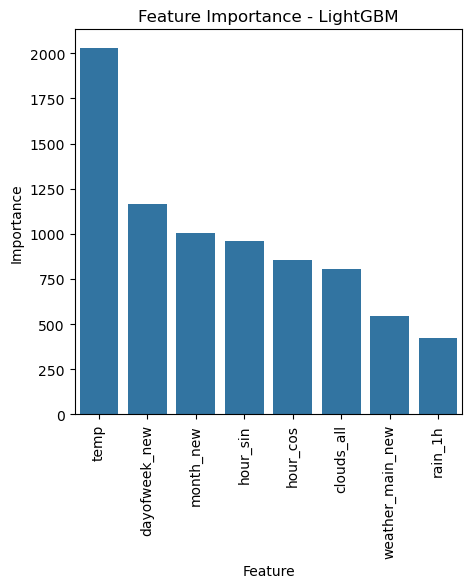

In [37]:
param_grid2 = {"n_estimators":[100,200,300],"learning_rate":[0.01,0.05,0.1,0.2],"num_leaves":[20,31,40,50],
               "max_depth":[-1,4,5,6],"subsample":[0.7,0.8,0.9,1],"colsample_bytree":[0.7,0.8,0.9,1]}

lgbm_model = LGBMRegressor(random_state=42, subsample_freq=1, verbose=-1) 

lgbm_random_search = RandomizedSearchCV(estimator=lgbm_model,param_distributions=param_grid2, n_iter=10, scoring="r2",cv=3,verbose=0,
                                        random_state=42,n_jobs=2) 

lgbm_random_search.fit(X_train,y_train) 

print("\nBest Parameters found:", lgbm_random_search.best_params_) 

lgbm_model_tuned = lgbm_random_search.best_estimator_  

y_pred_lgbm2 = lgbm_model_tuned.predict(X_test)

from sklearn.metrics import (mean_absolute_error,r2_score, root_mean_squared_error) 
print("R2 score:",r2_score(y_test, y_pred_lgbm2))
print("RMSE :",root_mean_squared_error(y_test, y_pred_lgbm2)) 
print("MAE:",mean_absolute_error(y_test, y_pred_lgbm2))

# FEATURE IMPORTANCE 
df_importance3 = pd.DataFrame({"Feature":X_train.columns, "Importance":lgbm_model_tuned.feature_importances_}) 
df_importance3 = df_importance3.sort_values(by="Importance", ascending=False) 
print(df_importance3) 

# plotting graph 
plt.figure(figsize=(5,5))
sns.barplot(data=df_importance3, x="Feature", y="Importance")
plt.xticks(rotation=90)
plt.title("Feature Importance - LightGBM") 
plt.show()

<h1>FINAL ENSEMBLE MODEL - 55% LightGBM & 45% XGBoost</h1>

In [38]:
# defining required weights to both Models 
lgbm_weight = 0.55
xgb_weight = 0.45 

# create weighted ensemble prediction 
y_pred_ensemble = (lgbm_weight * y_pred_lgbm2) + (xgb_weight * y_pred_xgb2) 

from sklearn.metrics import (mean_absolute_error,r2_score, root_mean_squared_error)
print("Final Model Performance ----->")
print("R2 score:",r2_score(y_test, y_pred_ensemble))
print("RMSE :",root_mean_squared_error(y_test, y_pred_ensemble)) 
print("MAE:",mean_absolute_error(y_test, y_pred_ensemble))


Final Model Performance ----->
R2 score: 0.9576590549093738
RMSE : 411.43158886939045
MAE: 245.59913594901235


<h3>Saving Models using Joblib</h3>

In [39]:
import joblib 

xgb_traffic = "xgboost_tuned.joblib" 
lgbm_traffic = "lightgbm_tuned.joblib" 

print("Saving Models for Streamlit Deployment") 
joblib.dump(xgb_model_tuned, xgb_traffic) 
joblib.dump(lgbm_model_tuned, lgbm_traffic) 

print("Saved successfully")

Saving Models for Streamlit Deployment
Saved successfully
